In [116]:
from deep_kolmogorov import modeling, pdes, trainer
import torch

model = modeling.KolmogorovNet(modeling.DeepONet(1,{"size_t_s_u": [1,1,3], "num_depth" : 6, "num_width" : 55}), pdes.BSr())
path = "./exp/avg_bs_r_2023_10_02_00_58_02/Trainer_2023-10-02_00-58-02/Trainer_aed00_00005_5_num_depth=6,num_width=55,seed=0_2023-10-02_00-58-02/checkpoint_000030"
model.net.load_state_dict(torch.load(f"{path}/model.pth", map_location=torch.device('cuda')))

<All keys matched successfully>

In [123]:
def get_option_price_curve(model, K, num_path, config):
    device = torch.device("cuda")
    with torch.no_grad(): 
        data = {
            key: torch.full(((K+1)*num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
        }
        data.update(
            {
                "t": torch.linspace(model.pde.hypercubes["t"].interval[0], model.pde.hypercubes["t"].interval[1], K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
            }
        )
        
        batch = {
            key: torch.full((num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
        }
        x = torch.full((num_path,K+1), 1, dtype=torch.float32, device=device)
        for i in range(K+1):
            x[:,i] = batch["s"].squeeze(1).clone()
            dw = (1/K)** 0.5  * torch.randn(
                batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device
            )
            batch["s"] = batch["s"] * torch.exp(
                batch["r"] * 1/K - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw
            )

        data["x"] = x.reshape(-1,1)
        data["K"] = model.pde.get_K(data)
        tensor = model.pde.normalize_and_flatten(data)
        y_pred = model.net.forward(tensor)
        y_true = model.pde.solution(data)
    return {
        "t": data["t"].reshape(num_path, K+1),
        "y_pred": y_pred.reshape(num_path, K+1),
        "y_true": y_true.reshape(num_path, K+1)
        }


In [108]:
x = torch.cuda.FloatTensor(3, 1).fill_(1)
x.dtype

torch.float32

In [129]:
import matplotlib.pyplot as plt

def plot_mc_curves(t_test, y_pred, y_true=None):
    if t_test.device != "cpu":
        t_test= t_test.cpu()
    if y_pred.device != "cpu":
        y_pred= y_pred.cpu()
    if y_true.device != "cpu":
        y_true= y_true.cpu()
    import matplotlib.pyplot as plt
    samples = 16
    plt.figure(figsize=(13, 8))
    plt.plot(t_test[0:1,:].T, y_pred[0:1,:].T,'darkviolet',label='Learned solution')
    plt.plot(t_test[0:1,:].T, y_true[0:1,:].T,'--',color='lightseagreen',label='Exact solution')
    plt.plot(t_test[0:1,-1], y_true[0:1,-1],'ko')

    plt.plot(t_test[1:samples,:].T, y_pred[1:samples,:].T,'darkviolet')
    plt.plot(t_test[1:samples,:].T, y_true[1:samples,:].T,'--',color='lightseagreen')
    plt.plot(t_test[1:samples,-1], y_true[1:samples,-1],'ko')

    plt.plot([0],y_true[0,0],'ks') # ,label='$Y_0 = u(0,X_0)$')

    plt.xlabel('time', fontdict={"size": 18})
    plt.ylabel('price', fontdict={"size": 18})
    #plt.title(fr'm={u_hat[-1]: 2f}, r={u_hat[0]: 2f}, $\theta$={u_hat[1]: 2f},$\kappa$={u_hat[2]: 2f}， $\sigma$={u_hat[3]: 2f}, $\rho$={u_hat[4]: 2f}')# , $\rho$={u_hat[2]: 2f}')
    plt.legend(prop={"size": 15})
    plt.show()

# res = get_option_price_curve(model, 100, 2, {"s":9.5, "r":0.03, "sigma": 0.3, "kappa":1.05})
# plot_mc_curves(res["t"], res["y_pred"], res["y_true"])


In [110]:
((res["y_pred"] - res["y_true"]).abs()/(res["y_true"]+1)).mean()


tensor(0.5023)

In [120]:
config = {'gpus': 1, 'mode': 'avg_bs_r', 'checkpoint': True, 'pde': 'BSr', 'net': 'DeepONet', 'norm_layer': 'layernorm', 'opt': 'adamw', 'bs': 131072, 'lr': 0.01, 'min_lr': 1e-08, 'weight_decay': 0.01, 'lr_decay': 0.25, 'lr_decay_patience': 2, 'unfreeze': 'all', 'unfreeze_patience': 1, 'levels': 4, 'factor': 6, 'n_iterations': 30, 'n_train_batches': 2000, 'n_test_batches': 150, 'resume_exp': None, 'size_t_s_u': [1, 1, 3], 'num_depth': 6, 'num_width': 55}

mytrainer = trainer.Trainer(config)
path = "./exp/avg_bs_r_2023_10_02_00_58_02/Trainer_2023-10-02_00-58-02/Trainer_aed00_00005_5_num_depth=6,num_width=55,seed=0_2023-10-02_00-58-02/checkpoint_000030/model.pth"
mytrainer.load_checkpoint(path)

mytrainer.model


2023-10-03 01:51:37,860	INFO trainable.py:172 -- Trainable.setup took 11.165 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


DataParallel(
  (module): KolmogorovNet(
    (net): DeepONet(
      (branch): DenseNet(
        (bn_layers): ModuleList(
          (0): BatchNorm1d(3, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
          (1): BatchNorm1d(55, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
          (2): BatchNorm1d(55, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
          (3): BatchNorm1d(55, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
          (4): BatchNorm1d(55, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
          (5): BatchNorm1d(55, eps=1e-06, momentum=0.99, affine=True, track_running_stats=True)
        )
        (dense_layers): ModuleList(
          (0): Linear(in_features=3, out_features=55, bias=True)
          (1): Linear(in_features=55, out_features=55, bias=True)
          (2): Linear(in_features=55, out_features=55, bias=True)
          (3): Linear(in_features=55, out_features=55, bias=T

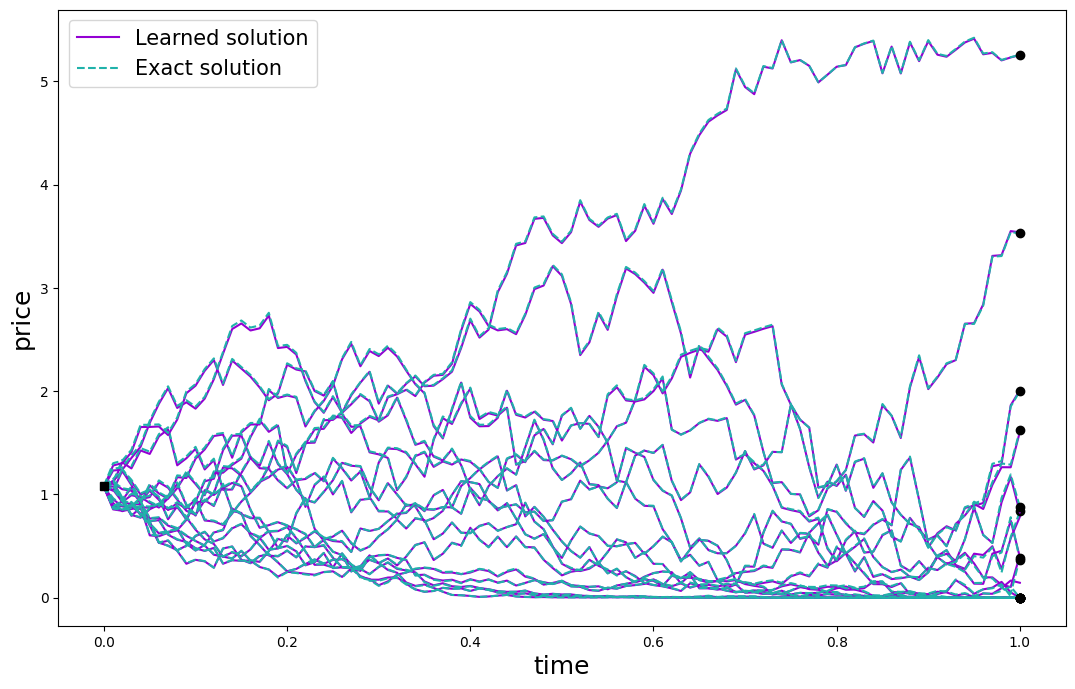

In [135]:
res = get_option_price_curve(mytrainer.model.module, 100, 16, {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01})
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])